In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from datetime import datetime #Para manejar el tiempo

In [2]:
data = pd.read_csv("Accidentalidad_en_Barranquilla_20260602.csv")
data.head(5)

,FECHA_ACCIDENTE,HORA_ACCIDENTE,GRAVEDAD_ACCIDENTE,CLASE_ACCIDENTE,SITIO_EXACTO_ACCIDENTE,CANT_HERIDOS_EN _SITIO_ACCIDENTE,CANT_MUERTOS_EN _SITIO_ACCIDENTE,CANTIDAD_ACCIDENTES,AÑO_ACCIDENTE,MES_ACCIDENTE,DIA_ACCIDENTE
0,2018-01-01T00:00:00.000,01:30:00:am,Con heridos,Atropello,CL 87 9H 24,1.0,NaN,1,2018,January,Mon
1,2018-01-01T00:00:00.000,02:00:00:pm,Solo daños,Choque,CL 110 CR 46,NaN,NaN,1,2018,January,Mon
2,2018-01-01T00:00:00.000,04:00:00:am,Solo daños,Choque,AV CIRCUNVALAR CR 9G,NaN,NaN,1,2018,January,Mon
3,2018-01-01T00:00:00.000,04:30:00:am,Solo daños,Choque,CLLE 72 CRA 29,NaN,NaN,1,2018,January,Mon
4,2018-01-01T00:00:00.000,05:20:00:pm,Solo daños,Choque,VIA 40 CALLE 75,NaN,NaN,1,2018,January,Mon


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28328 entries, 0 to 28327
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   FECHA_ACCIDENTE                   28328 non-null  str    
 1   HORA_ACCIDENTE                    28328 non-null  str    
 2   GRAVEDAD_ACCIDENTE                28328 non-null  str    
 3   CLASE_ACCIDENTE                   28328 non-null  str    
 4   SITIO_EXACTO_ACCIDENTE            28328 non-null  str    
 5   CANT_HERIDOS_EN _SITIO_ACCIDENTE  12641 non-null  float64
 6   CANT_MUERTOS_EN _SITIO_ACCIDENTE  328 non-null    float64
 7   CANTIDAD_ACCIDENTES               28328 non-null  int64  
 8   AÑO_ACCIDENTE                     28328 non-null  int64  
 9   MES_ACCIDENTE                     28328 non-null  str    
 10  DIA_ACCIDENTE                     28328 non-null  str    
dtypes: float64(2), int64(2), str(7)
memory usage: 2.4 MB


In [4]:
# Evaluando cantidad de accidentes mayores que 1
data[data["CANTIDAD_ACCIDENTES"] >= 2]

,FECHA_ACCIDENTE,HORA_ACCIDENTE,GRAVEDAD_ACCIDENTE,CLASE_ACCIDENTE,SITIO_EXACTO_ACCIDENTE,CANT_HERIDOS_EN _SITIO_ACCIDENTE,CANT_MUERTOS_EN _SITIO_ACCIDENTE,CANTIDAD_ACCIDENTES,AÑO_ACCIDENTE,MES_ACCIDENTE,DIA_ACCIDENTE
2602,2018-06-09T00:00:00.000,09:35:00:am,Solo daños,Choque,CARRERA 38 CALLE 52,NaN,NaN,2,2018,June,Sat
11516,2019-12-28T00:00:00.000,12:28:00:pm,Solo daños,Choque,CR 38 CL 81,NaN,NaN,2,2019,December,Sat
12038,2020-02-06T00:00:00.000,09:00:00:am,Solo daños,Choque,AV CIRCUNVALAR CR 27,NaN,NaN,2,2020,February,Thu
12837,2020-05-02T00:00:00.000,07:40:00:pm,Solo daños,Choque,CR 46 87 27,NaN,NaN,2,2020,May,Sat
14166,2020-11-05T00:00:00.000,05:25:00:pm,Solo daños,Choque,AV 110 CR 35,NaN,NaN,2,2020,November,Thu


In [5]:
## Hay muy pocos accidentes agrupados (solo 4), se decide eliminarlos para facilitar calculos
data = data[data["CANTIDAD_ACCIDENTES"] < 2]

In [6]:
## El año de realización de este notebook es 2026-06-08. Los datos del 2026 están incompletos con respecto a los meses.
data[data["AÑO_ACCIDENTE"] == 2026]["MES_ACCIDENTE"].unique()

<StringArray>
['Enero', 'Febrero', 'Marzo']
Length: 3, dtype: str

In [7]:
print("Datos a eliminar: ", len(data[data["AÑO_ACCIDENTE"] == 2026]))
data = data[data["AÑO_ACCIDENTE"] != 2026]

Datos a eliminar:  309


In [8]:
## Con los cambios
data.info()

<class 'pandas.DataFrame'>
Index: 28014 entries, 0 to 28018
Data columns (total 11 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   FECHA_ACCIDENTE                   28014 non-null  str    
 1   HORA_ACCIDENTE                    28014 non-null  str    
 2   GRAVEDAD_ACCIDENTE                28014 non-null  str    
 3   CLASE_ACCIDENTE                   28014 non-null  str    
 4   SITIO_EXACTO_ACCIDENTE            28014 non-null  str    
 5   CANT_HERIDOS_EN _SITIO_ACCIDENTE  12342 non-null  float64
 6   CANT_MUERTOS_EN _SITIO_ACCIDENTE  314 non-null    float64
 7   CANTIDAD_ACCIDENTES               28014 non-null  int64  
 8   AÑO_ACCIDENTE                     28014 non-null  int64  
 9   MES_ACCIDENTE                     28014 non-null  str    
 10  DIA_ACCIDENTE                     28014 non-null  str    
dtypes: float64(2), int64(2), str(7)
memory usage: 2.6 MB


In [9]:
# Probablemente los datos nulos sean registros 0, para comprobar:

print("CANT_MUERTOS COUNT:", data["CANT_MUERTOS_EN _SITIO_ACCIDENTE"].count())
print("GRAVEDAD_ACCIDENTE WITH DEADS:", data[data["GRAVEDAD_ACCIDENTE"] == "Con muertos"].count()["GRAVEDAD_ACCIDENTE"])

print("CANT_HERIDOS COUNT:", data["CANT_HERIDOS_EN _SITIO_ACCIDENTE"].count())
print("GRAVEDAD_ACCIDENTE WITH INJURED:", data[data["GRAVEDAD_ACCIDENTE"] == "Con heridos"].count()["GRAVEDAD_ACCIDENTE"])

CANT_MUERTOS COUNT: 314
GRAVEDAD_ACCIDENTE WITH DEADS: 314
CANT_HERIDOS COUNT: 12342
GRAVEDAD_ACCIDENTE WITH INJURED: 12236


In [10]:
# Los anteriores datos concuerdan, se procede a hacer fillna

data = data.fillna(0)
data.head(3)

,FECHA_ACCIDENTE,HORA_ACCIDENTE,GRAVEDAD_ACCIDENTE,CLASE_ACCIDENTE,SITIO_EXACTO_ACCIDENTE,CANT_HERIDOS_EN _SITIO_ACCIDENTE,CANT_MUERTOS_EN _SITIO_ACCIDENTE,CANTIDAD_ACCIDENTES,AÑO_ACCIDENTE,MES_ACCIDENTE,DIA_ACCIDENTE
0,2018-01-01T00:00:00.000,01:30:00:am,Con heridos,Atropello,CL 87 9H 24,1.0,0.0,1,2018,January,Mon
1,2018-01-01T00:00:00.000,02:00:00:pm,Solo daños,Choque,CL 110 CR 46,0.0,0.0,1,2018,January,Mon
2,2018-01-01T00:00:00.000,04:00:00:am,Solo daños,Choque,AV CIRCUNVALAR CR 9G,0.0,0.0,1,2018,January,Mon


<Axes: xlabel='AÑO_ACCIDENTE', ylabel='count'>

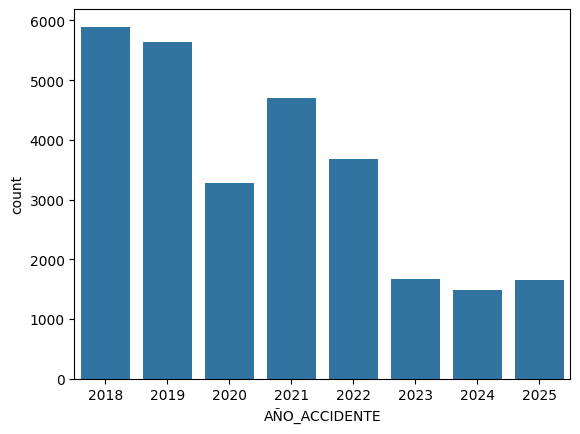

In [11]:
## Distribución de año de registro de los accidentes

sns.countplot(data=data, x="AÑO_ACCIDENTE")

### Más accidentes en anteriores años o simplemente más registro?

In [12]:
## Cambiar formato de la hora

data["HORA_ACCIDENTE"] = data["HORA_ACCIDENTE"].apply(lambda x: datetime.strptime(x, "%I:%M:%S:%p")) #Usa la libreria para transforar la hora
# data["HORA_ACCIDENTE"] = data["HORA_ACCIDENTE"].apply(lambda x: datetime.strftime(x, "%H:%M:%S")) # A 24 horas
data.head(3)

,FECHA_ACCIDENTE,HORA_ACCIDENTE,GRAVEDAD_ACCIDENTE,CLASE_ACCIDENTE,SITIO_EXACTO_ACCIDENTE,CANT_HERIDOS_EN _SITIO_ACCIDENTE,CANT_MUERTOS_EN _SITIO_ACCIDENTE,CANTIDAD_ACCIDENTES,AÑO_ACCIDENTE,MES_ACCIDENTE,DIA_ACCIDENTE
0,2018-01-01T00:00:00.000,1900-01-01 01:30:00,Con heridos,Atropello,CL 87 9H 24,1.0,0.0,1,2018,January,Mon
1,2018-01-01T00:00:00.000,1900-01-01 14:00:00,Solo daños,Choque,CL 110 CR 46,0.0,0.0,1,2018,January,Mon
2,2018-01-01T00:00:00.000,1900-01-01 04:00:00,Solo daños,Choque,AV CIRCUNVALAR CR 9G,0.0,0.0,1,2018,January,Mon


<Axes: xlabel='HORA_ACCIDENTE', ylabel='count'>

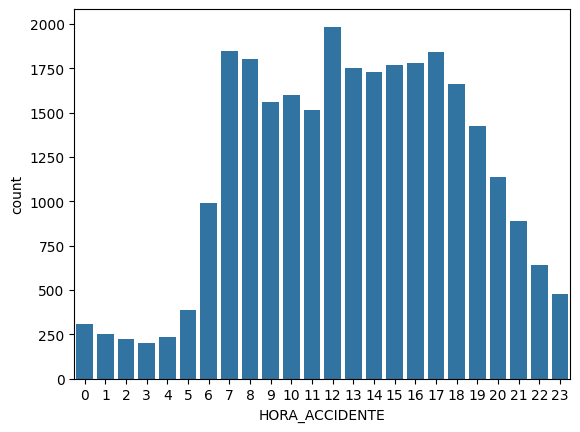

In [13]:
sns.countplot(data=data, x=data["HORA_ACCIDENTE"].dt.hour)

### Picos a las 7, 12 y 17.

In [14]:
data["DIA_ACCIDENTE"].unique()

<StringArray>
['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
Length: 7, dtype: str

In [15]:
# dias_ingles = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
# dias_espanol = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]

# data["DIA_ACCIDENTE"] = data["DIA_ACCIDENTE"].replace(dias_ingles, dias_espanol)
# data.head(5)

<Axes: xlabel='DIA_ACCIDENTE', ylabel='count'>

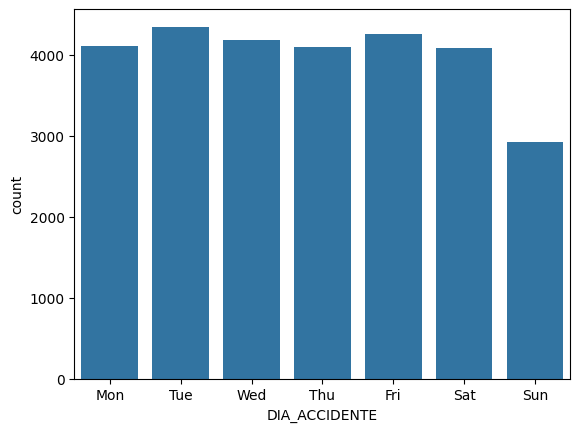

In [16]:
# Acumulados de accidente por dia de semana
sns.countplot(data=data, x="DIA_ACCIDENTE")

In [17]:
data["MES_ACCIDENTE"].unique()

<StringArray>
[  'January',  'February',     'March',     'April',       'May',      'June',
      'July',    'August', 'September',   'October',  'November',  'December']
Length: 12, dtype: str

In [18]:
# ## Mover todos los datos a español
# meses_ingles = ["January", "February", "March", "April", "May", "June", 
#                 "July", "August", "September", "October", "November", "December"]

# meses_espanol = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio", 
#                  "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

# data["MES_ACCIDENTE"] = data["MES_ACCIDENTE"].replace(meses_ingles, meses_espanol)

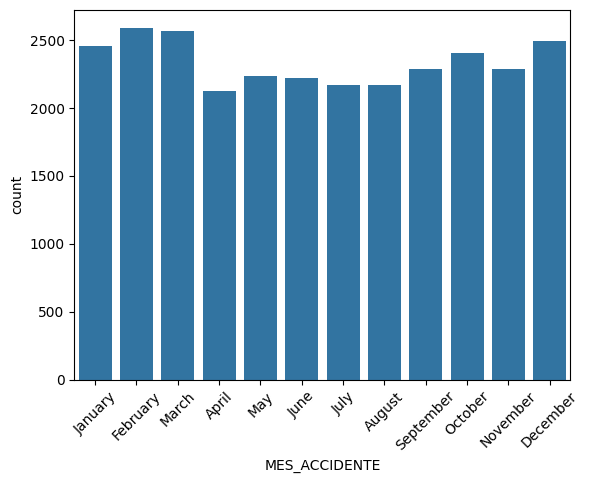

In [19]:
# Días del mes donde hay más accidentes
sns.countplot(data=data, x="MES_ACCIDENTE")
plt.xticks(rotation=45)
plt.show()

In [20]:
data["SITIO_EXACTO_ACCIDENTE"].unique()

<StringArray>
[                 'CL 87 9H 24',                 'CL 110 CR 46',
         'AV CIRCUNVALAR CR 9G',               'CLLE 72 CRA 29',
              'VIA 40 CALLE 75',                   'CR 8 CL 41',
            'CLLE 119B CRA 11B',             'CARRERA 25 37-42',
                 'CR 51B 1D 35',              'VIA 40  CLLE 85',
 ...
         'CARRERA 21B N° 64-78',         'CALLE 76 CARERRA 49C',
 'CARRERA 15 SUR CON CALLE 90A',          'CALLE 60A CARRERA 6',
     'CARRERA 37 CON CALLE 108',      'CARRERA 27 CON CALLE 58',
      'CALLE 53 CON CARRERA 37',      'CALLE 15 SUR CARRERA 48',
             'CALLE 45 G CRA 4',      'CALLE 14 CON CARRERA 23']
Length: 16754, dtype: str

In [21]:
hot_spots = data["SITIO_EXACTO_ACCIDENTE"].value_counts().head(8)
hot_spots

SITIO_EXACTO_ACCIDENTE
CL 110 CR 9G            77
CL 110 CR 6             66
CL 110 CR 43            55
CL 30 CR 8              53
VIA 40 CL 85            53
CL 17 CR 8              53
CL 110 CR 38            49
AV CIRCUNVALAR CR 9G    41
Name: count, dtype: int64

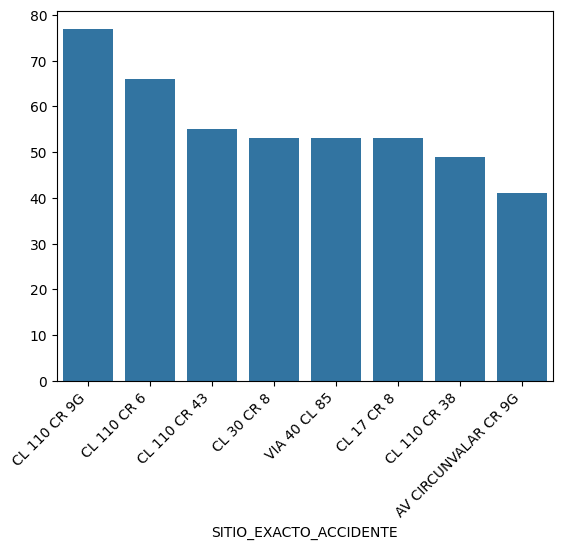

In [22]:
sns.barplot(x=hot_spots.index, y=hot_spots.values)
plt.xticks(rotation=45, ha="right")
plt.show()

In [23]:
## Información de fatalidad y proporción muertes/accidente.

In [24]:
data.columns

Index(['FECHA_ACCIDENTE', 'HORA_ACCIDENTE', 'GRAVEDAD_ACCIDENTE',
       'CLASE_ACCIDENTE', 'SITIO_EXACTO_ACCIDENTE',
       'CANT_HERIDOS_EN _SITIO_ACCIDENTE', 'CANT_MUERTOS_EN _SITIO_ACCIDENTE',
       'CANTIDAD_ACCIDENTES', 'AÑO_ACCIDENTE', 'MES_ACCIDENTE',
       'DIA_ACCIDENTE'],
      dtype='str')

In [25]:
data["GRAVEDAD_ACCIDENTE"].unique()

<StringArray>
['Con heridos', 'Solo daños', 'Con muertos']
Length: 3, dtype: str

In [26]:
muertes = len(data[data["GRAVEDAD_ACCIDENTE"] == "Con muertos"])
total = len(data)
print("Accidentes con muertes en el sitio: ", muertes)
print("Proporción muertes: %", round((muertes/total)*100, 2))

Accidentes con muertes en el sitio:  314
Proporción muertes: % 1.12


In [27]:
heridos = len(data[data["GRAVEDAD_ACCIDENTE"] == "Con heridos"])
print("Accidentes con heridos en el sitio: ", heridos)
print("Proporción de heridos: %", round((heridos/total)*100, 2))

Accidentes con heridos en el sitio:  12236
Proporción de heridos: % 43.68


In [28]:
## Como la información viene del registro de transito solo se sabe las muertes ocurridas en el instante de registro del accidente, no se tiene conocimiento sobre muertes posteriores

<Axes: xlabel='HORA_ACCIDENTE', ylabel='count'>

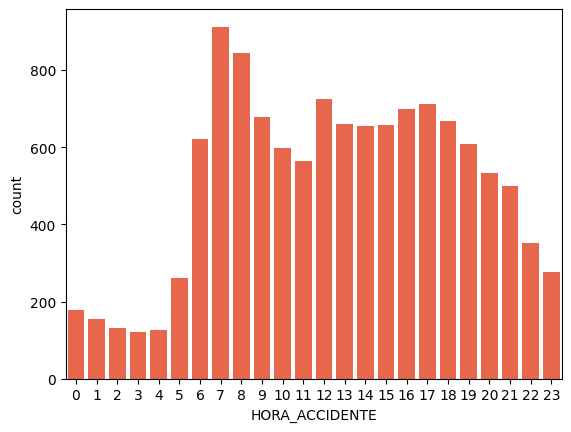

In [29]:
injured = data[data["GRAVEDAD_ACCIDENTE"] == "Con heridos"]["HORA_ACCIDENTE"].dt.hour
sns.countplot(x=injured, color="#FF5733")

In [30]:
is_injured = data["GRAVEDAD_ACCIDENTE"] == "Con heridos"
is_injured.head(3)

0     True
1    False
2    False
Name: GRAVEDAD_ACCIDENTE, dtype: bool

In [31]:
hours = data["HORA_ACCIDENTE"].dt.hour

In [32]:
injured_proportion = is_injured.groupby(hours).mean()
injured_proportion.head(3)

HORA_ACCIDENTE
0    0.572347
1    0.612648
2    0.582222
Name: GRAVEDAD_ACCIDENTE, dtype: float64

<Axes: xlabel='HORA_ACCIDENTE'>

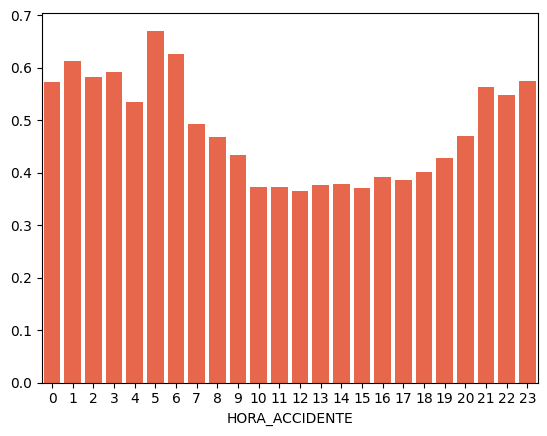

In [33]:
sns.barplot(x=injured_proportion.index, y=injured_proportion.values, color="#FF5733")